# Smart Home IoT — ML Pipeline
### ThingSpeak Channel 3322758 | Random Forest Motion Prediction
**Team:** Alima Babakpayeva · Malike Nurpeiis · Dayana Makulbayeva  
**Supervisor:** Aigerim Kalikova  
**Astana IT University, 2026**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import requests
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

CHANNEL_ID   = 3322758
READ_API_KEY = '1FIQPR7VZSQ2L47H'
N_RESULTS    = 1000

print('✓ Все библиотеки загружены')
print(f'  pandas  {pd.__version__} | numpy {np.__version__}')


✓ Все библиотеки загружены
  pandas  2.2.2 | numpy 2.0.2


In [26]:
url = (
    f'https://api.thingspeak.com/channels/{CHANNEL_ID}/feeds.json'
    f'?api_key={READ_API_KEY}&results={N_RESULTS}'
)

print(f'Загружаем данные: {url}')
try:
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    raw = r.json()
    feeds = raw['feeds']
    print(f'✓ Получено {len(feeds)} записей из ThingSpeak')
except Exception as e:
    print(f'⚠ Ошибка сети: {e}')

    import os
    csv_files = [f for f in os.listdir('/content') if f.endswith('.csv')]
    print(f'  CSV файлы в /content: {csv_files}')
    feeds = None


Загружаем данные: https://api.thingspeak.com/channels/3322758/feeds.json?api_key=1FIQPR7VZSQ2L47H&results=1000
✓ Получено 1000 записей из ThingSpeak


In [29]:
import os

if feeds is not None:
    df = pd.DataFrame(feeds)
    df = df.rename(columns={
        'field1': 'temperature',
        'field2': 'humidity',
        'field3': 'light',
        'field4': 'motion',
        'field5': 'relay',
        'field6': 'voc'
    })
    keep = ['created_at','temperature','humidity','light','motion','relay','voc']
    df = df[[c for c in keep if c in df.columns]].copy()
else:
    csv_candidates = [
        '/content/feeds-3.csv',
        '/content/feeds.csv',
        '/content/feeds-2.csv',
    ]
    csv_path = None
    for p in csv_candidates:
        if os.path.exists(p):
            csv_path = p
            break

    if csv_path is None:
        all_csv = [f'/content/{f}' for f in os.listdir('/content') if f.endswith('.csv')]
        if all_csv:
            csv_path = all_csv[0]

    if csv_path:
        print(f'✓ Читаем файл: {csv_path}')
        df = pd.read_csv(csv_path)
        print(f'  Колонки: {list(df.columns)}')
        rename_map = {
            'field1': 'temperature', 'field2': 'humidity',
            'field3': 'light',       'field4': 'motion',
            'field5': 'relay',       'field6': 'voc'
        }
        df = df.rename(columns=rename_map)
    else:
        raise FileNotFoundError('Нет данных! Загрузите feeds.csv в Colab через Files → Upload')

df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
df = df.dropna(subset=['created_at'])
df = df.set_index('created_at').sort_index()

for col in ['temperature','humidity','light','motion','relay','voc']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[df['temperature'] > 0].copy()

print(f'Всего записей      : {len(df)}')
print(f'После очистки      : {len(df_clean)}')
print(f'Период             : {df_clean.index.min()} → {df_clean.index.max()}')
print(f'Колонки            : {list(df_clean.columns)}')
print(f'''Пропуски:
{df_clean.isnull().sum()}''')
df_clean.head()

Всего записей      : 1000
После очистки      : 964
Период             : 2026-04-06 13:24:30+00:00 → 2026-05-28 06:57:37+00:00
Колонки            : ['temperature', 'humidity', 'light', 'motion', 'relay', 'voc']
Пропуски:
temperature    0
humidity       2
light          2
motion         2
relay          2
voc            2
dtype: int64


,temperature,humidity,light,motion,relay,voc
created_at,,,,,,
2026-04-06 13:24:30+00:00,24.05,33.48,125.0,0.0,1.0,98.0
2026-04-06 13:24:54+00:00,24.05,33.48,127.0,1.0,1.0,99.0
2026-04-06 13:25:15+00:00,24.05,33.48,117.0,0.0,1.0,99.0
2026-04-06 13:25:36+00:00,24.05,33.48,99.0,0.0,1.0,99.0
2026-04-06 13:25:57+00:00,24.05,33.48,116.0,1.0,1.0,99.0


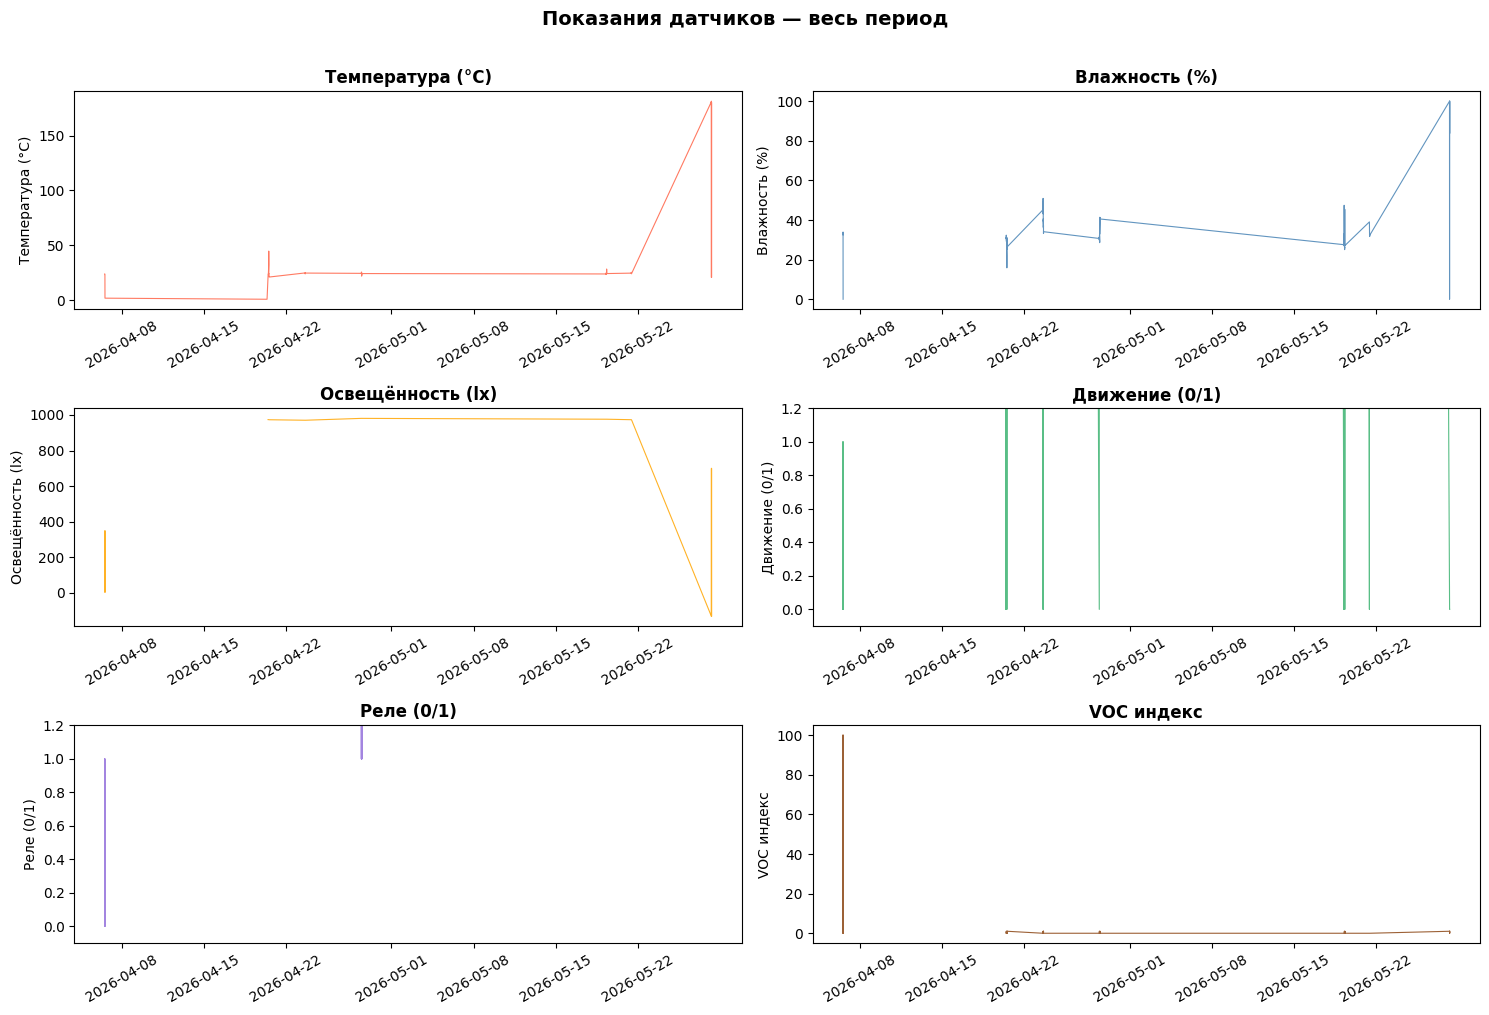


── Статистика по дням ───────────────────────────────────────────────
  2026-04-06  записей=  58  T=2.0–24.1°C  Motion=5  VOC_avg=58
  2026-04-20  записей= 210  T=1.0–44.9°C  Motion=19853  VOC_avg=0
  2026-04-23  записей= 129  T=24.2–25.3°C  Motion=12181  VOC_avg=0
  2026-04-28  записей= 266  T=22.1–25.8°C  Motion=35976  VOC_avg=0
  2026-05-19  записей= 192  T=23.7–28.5°C  Motion=17712  VOC_avg=0
  2026-05-21  записей=  60  T=24.2–25.5°C  Motion=5171  VOC_avg=0
  2026-05-28  записей=  49  T=20.8–181.3°C  Motion=0  VOC_avg=1


In [30]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

sensors = [
    ('temperature', 'Температура (°C)',  'tomato'),
    ('humidity',    'Влажность (%)',     'steelblue'),
    ('light',       'Освещённость (lx)', 'orange'),
    ('motion',      'Движение (0/1)',    'mediumseagreen'),
    ('relay',       'Реле (0/1)',        'mediumpurple'),
    ('voc',         'VOC индекс',        'saddlebrown'),
]

for i, (col, label, color) in enumerate(sensors):
    if col not in df_clean.columns:
        continue
    ax = axes[i]
    ax.plot(df_clean.index, df_clean[col], color=color, linewidth=0.8, alpha=0.85)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=30)
    if col in ('motion','relay'):
        ax.set_ylim(-0.1, 1.2)

plt.suptitle('Показания датчиков — весь период', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n── Статистика по дням ───────────────────────────────────────────────')
df_clean['date'] = df_clean.index.date
for d, g in df_clean.groupby('date'):
    print(f'  {d}  записей={len(g):4d}  '
          f'T={g.temperature.min():.1f}–{g.temperature.max():.1f}°C  '
          f'Motion={int(g.motion.sum())}  '
          f'VOC_avg={g.voc.mean():.0f}')
df_clean.drop(columns=['date'], inplace=True)


In [31]:
df_feat = df_clean.copy()

df_feat['hour']       = df_feat.index.hour
df_feat['minute']     = df_feat.index.minute
df_feat['day_of_week']= df_feat.index.dayofweek
df_feat['time_float'] = df_feat['hour'] + df_feat['minute'] / 60.0
df_feat['is_weekend'] = (df_feat['day_of_week'] >= 5).astype(int)

def build_target(df, ahead_min=2):
    times = df.index
    result = []
    for t in times:
        fut = t + timedelta(minutes=ahead_min)
        mask = (times >= fut - timedelta(minutes=1)) & (times <= fut + timedelta(minutes=1))
        # Fix: Ensure motion_in_2min is binary (0 or 1)
        result.append(1 if (mask.any() and df.loc[mask, 'motion'].max() > 0) else 0)
    return result

df_feat['motion_in_2min'] = build_target(df_feat)

print('Признаки добавлены. Форма:', df_feat.shape)
print('Распределение target (motion_in_2min):')
print(df_feat['motion_in_2min'].value_counts())
print(f'  Доля «движение будет»: {df_feat["motion_in_2min"].mean():.1%}')
df_feat[['hour','minute','temperature','humidity','light','motion','motion_in_2min']].head(8)

Признаки добавлены. Форма: (964, 12)
Распределение target (motion_in_2min):
motion_in_2min
1    834
0    130
Name: count, dtype: int64
  Доля «движение будет»: 86.5%


,hour,minute,temperature,humidity,light,motion,motion_in_2min
created_at,,,,,,,
2026-04-06 13:24:30+00:00,13,24,24.05,33.48,125.0,0.0,1
2026-04-06 13:24:54+00:00,13,24,24.05,33.48,127.0,1.0,1
2026-04-06 13:25:15+00:00,13,25,24.05,33.48,117.0,0.0,0
2026-04-06 13:25:36+00:00,13,25,24.05,33.48,99.0,0.0,0
2026-04-06 13:25:57+00:00,13,25,24.05,33.48,116.0,1.0,0
2026-04-06 13:26:42+00:00,13,26,24.05,33.48,106.0,0.0,0
2026-04-06 13:27:03+00:00,13,27,24.05,33.48,115.0,0.0,0
2026-04-06 13:27:24+00:00,13,27,24.05,33.48,115.0,0.0,0


In [33]:
FEATURE_COLS = ['hour', 'minute', 'temperature', 'humidity', 'light']

X = df_feat[FEATURE_COLS].dropna()
y = df_feat['motion_in_2min'].loc[X.index]

stratify = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f' Модель обучена  |  Train: {len(X_train)}  Test: {len(X_test)}')
print(f'\n Accuracy: {acc:.4f} ({acc*100:.1f}%) ')
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Нет движения','Движение'], zero_division=0))


 Модель обучена  |  Train: 769  Test: 193

 Accuracy: 0.9534 (95.3%) 

Classification Report:
              precision    recall  f1-score   support

Нет движения       0.84      0.81      0.82        26
    Движение       0.97      0.98      0.97       167

    accuracy                           0.95       193
   macro avg       0.91      0.89      0.90       193
weighted avg       0.95      0.95      0.95       193



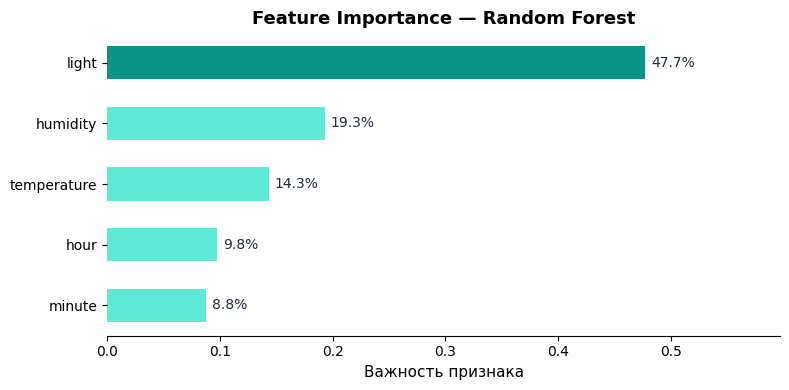

Топ признаков:
  light           0.4774  ███████████████████████
  humidity        0.1934  █████████
  temperature     0.1434  ███████
  hour            0.0977  ████
  minute          0.0880  ████


In [34]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#0D9488' if v == importances.max() else '#5EEAD4' for v in importances]
bars = ax.barh(importances.index, importances.values, color=colors, height=0.55)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, color='#1E293B')

ax.set_xlabel('Важность признака', fontsize=11)
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.25)
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

print('Топ признаков:')
for feat, imp in importances.sort_values(ascending=False).items():
    bar = '█' * int(imp * 50)
    print(f'  {feat:15s} {imp:.4f}  {bar}')


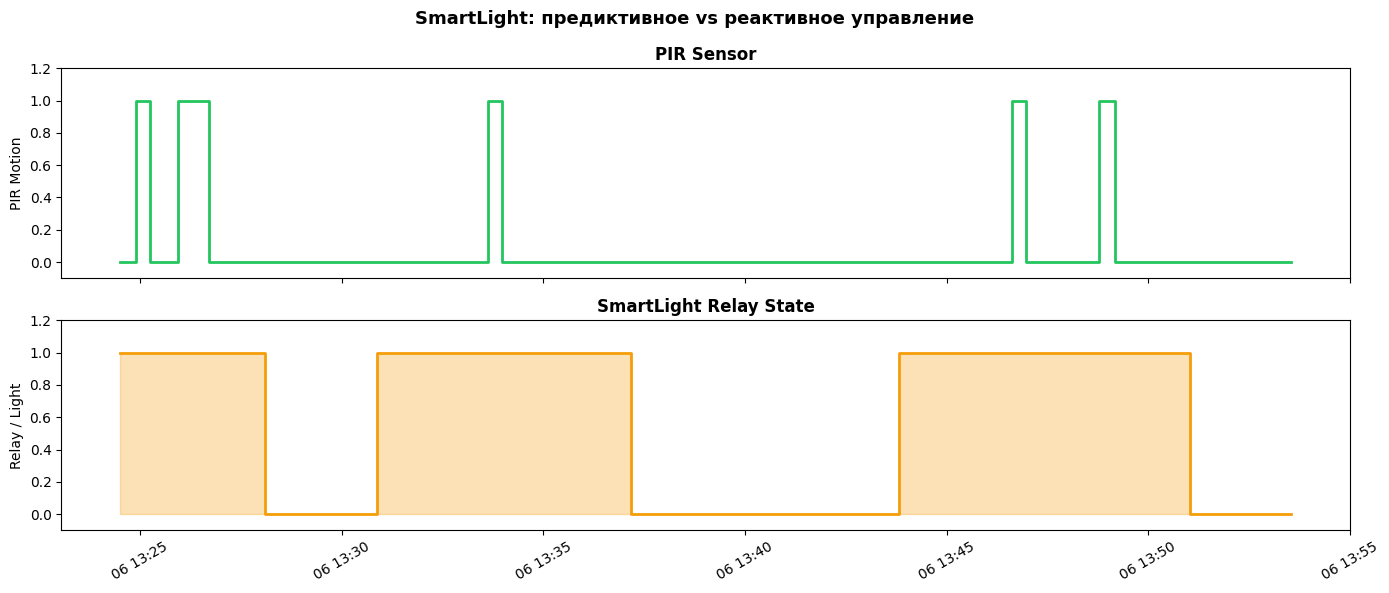

Свет включён: 32 из 58 шагов
Предиктивных включений: 3


In [36]:

class SmartLight:
    """Объединяет реактивное (PIR) и предиктивное (ML) управление светом."""

    TIMEOUT_STEPS = 5

    def __init__(self, rf_model):
        self.model          = rf_model
        self.light_on       = False
        self.no_motion_cnt  = 0

    def update(self, hour, minute, temp, hum, light_val, motion_now):
        feat = pd.DataFrame([
            {
                'hour': hour, 'minute': minute,
                'temperature': temp, 'humidity': hum, 'light': light_val
            }
        ])
        pred = self.model.predict(feat)[0]

        if motion_now:
            self.light_on, self.no_motion_cnt = True, 0
            return 'MOTION DETECTED  → 💡 ON'

        if pred and not self.light_on:
            self.light_on, self.no_motion_cnt = True, 0
            return 'ML PREDICTED     → 💡 ON  (smart)'

        if self.light_on:
            self.no_motion_cnt += 1
            if self.no_motion_cnt >= self.TIMEOUT_STEPS:
                self.light_on, self.no_motion_cnt = False, 0
                return f'TIMEOUT ({self.TIMEOUT_STEPS} steps) → 💡 OFF'
            return f'Waiting ({self.no_motion_cnt}/{self.TIMEOUT_STEPS})'

        return '💡 OFF'


ctrl   = SmartLight(model)
relevant_cols_for_simulation = FEATURE_COLS + ['motion']
sample = df_feat.head(60).dropna(subset=relevant_cols_for_simulation).copy()

times, motions, lights, actions_list = [], [], [], []
for ts, row in sample.iterrows():
    act = ctrl.update(
        int(row['hour']), int(row['minute']),
        row['temperature'], row['humidity'], row['light'],
        int(row['motion'])
    )
    times.append(ts)
    motions.append(int(row['motion']))
    lights.append(1 if ctrl.light_on else 0)
    actions_list.append(act)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.step(times, motions, where='post', color='#22C55E', linewidth=2)
ax1.set_ylabel('PIR Motion'); ax1.set_ylim(-0.1, 1.2)
ax1.set_title('PIR Sensor', fontweight='bold')

ax2.step(times, lights, where='post', color='#F59E0B', linewidth=2)
ax2.fill_between(times, 0, lights, step='post', alpha=0.3, color='#F59E0B')
ax2.set_ylabel('Relay / Light'); ax2.set_ylim(-0.1, 1.2)
ax2.set_title('SmartLight Relay State', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('SmartLight: предиктивное vs реактивное управление', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

on_steps = sum(lights)
print(f'Свет включён: {on_steps} из {len(lights)} шагов')
print(f'Предиктивных включений: {sum(1 for a in actions_list if "ML PREDICTED" in a)}')

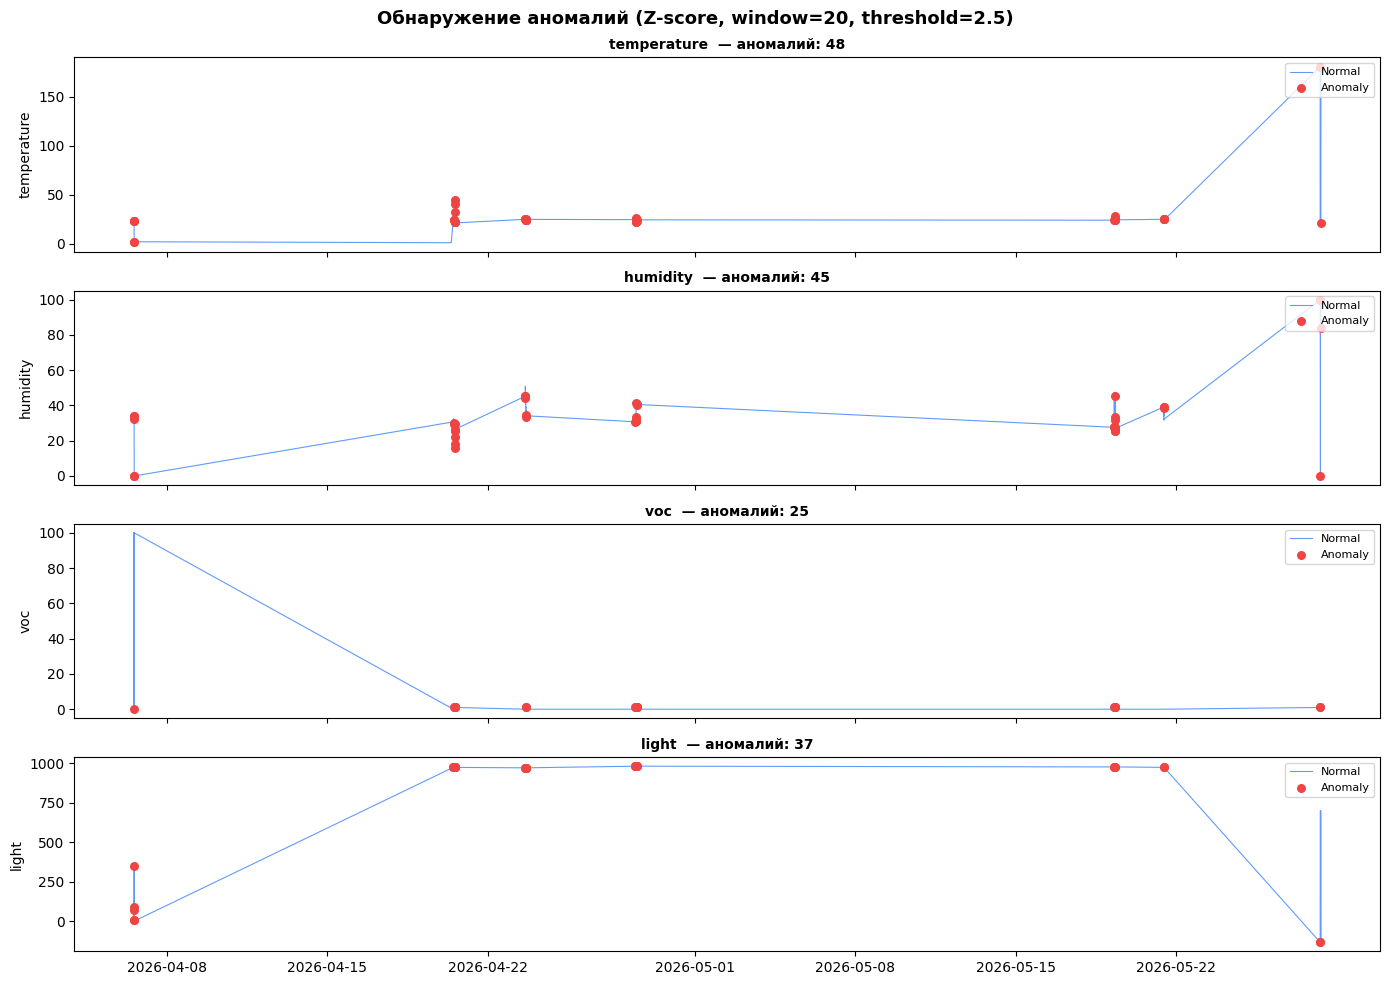


── Сводка аномалий ──────────────────────────────────────────────────
  temperature    :   48 аномалий из 964 точек (5.0%)
  humidity       :   45 аномалий из 962 точек (4.7%)
  voc            :   25 аномалий из 962 точек (2.6%)
  light          :   37 аномалий из 962 точек (3.8%)


In [37]:

def z_score_anomalies(series, window=20, threshold=2.5):
    """Возвращает булеву маску аномальных точек."""
    roll_mean = series.rolling(window, min_periods=3).mean()
    roll_std  = series.rolling(window, min_periods=3).std()
    z = ((series - roll_mean) / (roll_std + 1e-9)).abs()
    return z > threshold, z

cols_to_check = ['temperature', 'humidity', 'voc', 'light']
fig, axes = plt.subplots(len(cols_to_check), 1, figsize=(14, 10), sharex=True)

for ax, col in zip(axes, cols_to_check):
    if col not in df_clean.columns:
        continue
    s = df_clean[col].dropna()
    is_anom, z_vals = z_score_anomalies(s)

    ax.plot(s.index, s.values, color='#3B82F6', linewidth=0.8, alpha=0.8, label='Normal')
    ax.scatter(s[is_anom].index, s[is_anom].values,
               color='#EF4444', s=30, zorder=5, label='Anomaly')
    ax.set_ylabel(col, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    n_anom = is_anom.sum()
    ax.set_title(f'{col}  — аномалий: {n_anom}', fontsize=10, fontweight='bold')

plt.suptitle('Обнаружение аномалий (Z-score, window=20, threshold=2.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n── Сводка аномалий ──────────────────────────────────────────────────')
for col in cols_to_check:
    if col in df_clean.columns:
        s = df_clean[col].dropna()
        is_anom, _ = z_score_anomalies(s)
        print(f'  {col:15s}: {is_anom.sum():4d} аномалий из {len(s)} точек '
              f'({is_anom.mean()*100:.1f}%)')


Медианный интервал между записями: 0.5 мин

── Тренды (последние 20 точек) 
  temperature    : slope=-1.3359/sample  ↓ Падает
  humidity       : slope=-0.0605/sample  ↓ Падает
  voc            : slope=+0.0045/sample  → Стабильно

── 30-минутный прогноз температуры
  +10 мин → 150.4°C  (Δ-29.69°C)
  +20 мин → 120.7°C  (Δ-59.37°C)
  +30 мин → 91.0°C  (Δ-89.06°C)


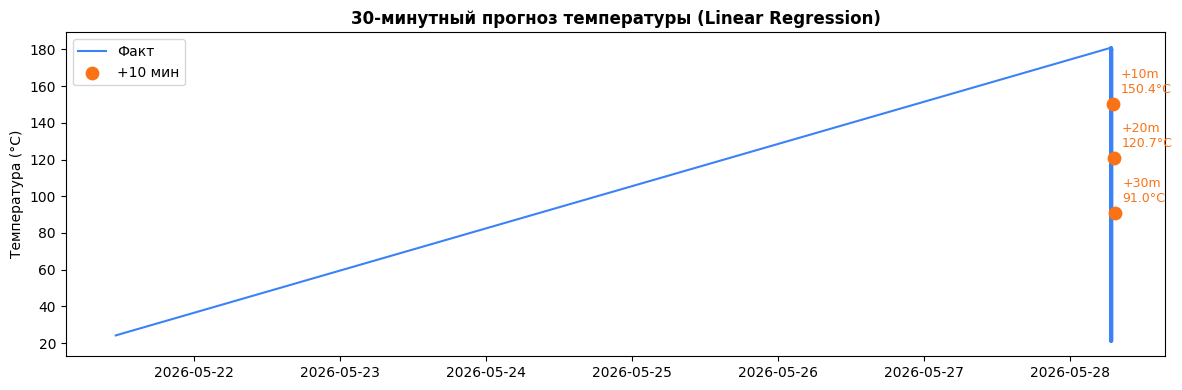

In [39]:
from sklearn.linear_model import LinearRegression

N_LAST = 20
FORECAST_MIN = [10, 20, 30]

def linear_trend(series, n=N_LAST):
    """slope в единицах/sample, прогноз через ahead шагов."""
    s = series.dropna().tail(n)
    if len(s) < 5:
        return 0.0, s.iloc[-1] if len(s) else 0.0
    X_lr = np.arange(len(s)).reshape(-1, 1)
    lr = LinearRegression().fit(X_lr, s.values)
    return float(lr.coef_[0]), float(lr.predict([[len(s)]])[0])

time_diffs = df_clean.index.to_series().diff().dt.total_seconds().div(60).dropna()
avg_interval = time_diffs.median()  # медиана надёжнее
if pd.isna(avg_interval) or avg_interval <= 0:
    avg_interval = 1.0
print(f'Медианный интервал между записями: {avg_interval:.1f} мин')

trend_cols = ['temperature', 'humidity', 'voc']
print('\n── Тренды (последние 20 точек) ')
for col in trend_cols:
    if col not in df_clean.columns:
        continue
    slope, _ = linear_trend(df_clean[col])
    direction = '↑ Растёт' if slope > 0.05 else ('↓ Падает' if slope < -0.05 else '→ Стабильно')
    print(f'  {col:15s}: slope={slope:+.4f}/sample  {direction}')

temp_series = df_clean['temperature'].dropna()
slope_t, next_val = linear_trend(temp_series)

steps_per_min = 1.0 / avg_interval
forecasts = {}
for m in FORECAST_MIN:
    steps = m * steps_per_min
    forecasts[m] = temp_series.iloc[-1] + slope_t * steps

print('\n── 30-минутный прогноз температуры')
for m, val in forecasts.items():
    diff = val - temp_series.iloc[-1]
    print(f'  +{m:2d} мин → {val:.1f}°C  (Δ{diff:+.2f}°C)')

last_n = temp_series.tail(50)
last_ts = last_n.index[-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(last_n.index, last_n.values, color='#3B82F6', linewidth=1.5, label='Факт')

for m, val in forecasts.items():
    ft = last_ts + timedelta(minutes=m)
    ax.scatter([ft], [val], s=80, zorder=5,
               color='#F97316', label=f'+{m} мин' if m == FORECAST_MIN[0] else '')
    ax.annotate(f'+{m}m\n{val:.1f}°C', (ft, val),
                textcoords='offset points', xytext=(5, 8), fontsize=9, color='#F97316')

trend_x = np.array([0, len(last_n) + 30 * steps_per_min])
trend_y = last_n.iloc[-1] + slope_t * (trend_x - len(last_n))
ax.set_title('30-минутный прогноз температуры (Linear Regression)', fontweight='bold')
ax.set_ylabel('Температура (°C)'); ax.legend()
plt.tight_layout(); plt.show()


In [40]:

class PersonalComfortLearner:
    """
    Обучается на поведении пользователя:
      • Открытие окна  → резкое падение VOC (diff < -15)
      • Ручное управление реле → включение без движения / выключение при движении
    """
    DEFAULT = dict(temp_min=18, temp_max=26,
                   hum_min=30,  hum_max=60,
                   voc_max=80)

    def __init__(self):
        self.thresholds = self.DEFAULT.copy()

    def fit(self, df):

        if 'voc' in df.columns:
            voc_drop = df['voc'].diff() < -15
            uncomfortable = df[voc_drop]
            if len(uncomfortable) > 0:
                avg_t = uncomfortable['temperature'].mean()
                avg_v = uncomfortable['voc'].mean()
                self.thresholds['temp_max'] = min(self.thresholds['temp_max'],
                                                   avg_t - 0.5)
                self.thresholds['voc_max']  = min(self.thresholds['voc_max'],
                                                   avg_v - 5)
                print(f'  Окно открывалось {len(uncomfortable)} раз(а) '
                      f'при T={avg_t:.1f}°C, VOC={avg_v:.0f}')

        if 'relay' in df.columns and 'motion' in df.columns:
            delta = df['relay'].diff()
            manual_on  = df[(delta == 1) & (df['motion'] == 0)]
            manual_off = df[(delta == -1) & (df['motion'] == 1)]
            if len(manual_on):
                print(f'  Реле включали вручную (без движения): '
                      f'{len(manual_on)} раз, ср. свет={manual_on["light"].mean():.0f} lx')
            if len(manual_off):
                print(f'  Реле выключали вручную (при движении): '
                      f'{len(manual_off)} раз')
        return self

    def check(self, temp, hum, voc):
        alerts = []
        t = self.thresholds
        if temp > t['temp_max']: alerts.append(f'🌡 Жарко: {temp:.1f}°C > {t["temp_max"]:.1f}°C')
        if temp < t['temp_min']: alerts.append(f'❄ Холодно: {temp:.1f}°C < {t["temp_min"]:.1f}°C')
        if hum  > t['hum_max']:  alerts.append(f'💧 Влажно: {hum:.0f}% > {t["hum_max"]:.0f}%')
        if hum  < t['hum_min']:  alerts.append(f'🏜 Сухо: {hum:.0f}% < {t["hum_min"]:.0f}%')
        if voc  > t['voc_max']:  alerts.append(f'🪟 Плохой воздух: VOC {voc:.0f} > {t["voc_max"]:.0f}')
        return alerts


print('── Обучение PersonalComfortLearner ')
learner = PersonalComfortLearner()
learner.fit(df_clean)

print('\n── Персональные пороги ')
for k, v in learner.thresholds.items():
    std = PersonalComfortLearner.DEFAULT[k]
    tag = '  ← изменён' if abs(v - std) > 0.01 else ''
    print(f'  {k:12s}: {v:.1f}  (стандарт: {std}){tag}')

# Пример проверки
print('\n── Пример alert-check ')
for t_, h_, v_ in [(28, 45, 70), (22, 50, 50), (15, 25, 95)]:
    alerts = learner.check(t_, h_, v_)
    status = ', '.join(alerts) if alerts else '✓ Всё в норме'
    print(f'  T={t_}°C H={h_}% VOC={v_}: {status}')


── Обучение PersonalComfortLearner 
  Окно открывалось 2 раз(а) при T=23.2°C, VOC=0
  Реле включали вручную (без движения): 16 раз, ср. свет=436 lx

── Персональные пороги 
  temp_min    : 18.0  (стандарт: 18)
  temp_max    : 22.7  (стандарт: 26)  ← изменён
  hum_min     : 30.0  (стандарт: 30)
  hum_max     : 60.0  (стандарт: 60)
  voc_max     : -5.0  (стандарт: 80)  ← изменён

── Пример alert-check 
  T=28°C H=45% VOC=70: 🌡 Жарко: 28.0°C > 22.7°C, 🪟 Плохой воздух: VOC 70 > -5
  T=22°C H=50% VOC=50: 🪟 Плохой воздух: VOC 50 > -5
  T=15°C H=25% VOC=95: ❄ Холодно: 15.0°C < 18.0°C, 🏜 Сухо: 25% < 30%, 🪟 Плохой воздух: VOC 95 > -5


── SDG Scoring (весь датасет) ────────────────────────────────────────
  SDG 3 — Здоровье              :  75%  ███████████████
  SDG 7 — Энергия               : 100%  ████████████████████
  SDG 11 — Города               : 100%  ████████████████████
  SDG 13 — Климат               :  48%  █████████
  OVERALL                       :  80%


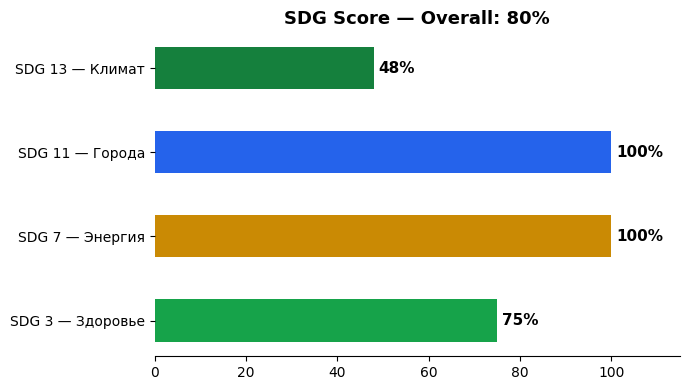

In [41]:

def sdg_score(df_window):
    """
    Вычисляет 4 SDG-оценки на основе реальных данных датчиков.
    Возвращает dict {sdg3, sdg7, sdg11, sdg13, overall}
    """
    scores = {}

    s3 = 100
    if 'voc' in df_window:
        voc_mean = df_window['voc'].mean()
        if voc_mean > 300: s3 -= 40
        elif voc_mean > 200: s3 -= 20
        elif voc_mean > 150: s3 -= 10
    if 'temperature' in df_window:
        t = df_window['temperature'].mean()
        if t < 16 or t > 30: s3 -= 25
        elif t < 18 or t > 26: s3 -= 10
    if 'humidity' in df_window:
        h = df_window['humidity'].mean()
        if h < 25 or h > 70: s3 -= 20
    scores['sdg3'] = max(0, s3)

    s7 = 100
    if 'relay' in df_window and 'motion' in df_window:
        relay_on  = df_window['relay'].mean()
        motion_on = df_window['motion'].mean()
        waste = max(0, relay_on - motion_on)  # свет горит без движения
        s7 -= int(waste * 60)
    scores['sdg7'] = max(0, s7)

    s11 = 80
    if len(df_window) > 100: s11 += 10
    if 'voc' in df_window and df_window['voc'].mean() < 150: s11 += 10
    scores['sdg11'] = min(100, s11)

    s13 = 100
    if 'temperature' in df_window:
        t = df_window['temperature'].mean()
        if t < 18 or t > 22: s13 -= int(abs(t - 20) * 5)
    scores['sdg13'] = max(0, s13)

    scores['overall'] = int(np.mean(list(scores.values())))
    return scores


scores = sdg_score(df_clean)
print('── SDG Scoring (весь датасет) ────────────────────────────────────────')
labels = {'sdg3':'SDG 3 — Здоровье', 'sdg7':'SDG 7 — Энергия',
          'sdg11':'SDG 11 — Города', 'sdg13':'SDG 13 — Климат'}
for k, lbl in labels.items():
    bar = '█' * (scores[k] // 5)
    print(f'  {lbl:30s}: {scores[k]:3d}%  {bar}')
print(f"  {'OVERALL':30s}: {scores['overall']:3d}%")

# Визуализация
fig, ax = plt.subplots(figsize=(7, 4))
sdg_names = [labels[k] for k in labels]
sdg_vals  = [scores[k] for k in labels]
colors_sdg = ['#16A34A','#CA8A04','#2563EB','#15803D']
ax.barh(sdg_names, sdg_vals, color=colors_sdg, height=0.5)
for i, v in enumerate(sdg_vals):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 115)
ax.set_title(f'SDG Score — Overall: {scores["overall"]}%',
             fontsize=13, fontweight='bold')
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout(); plt.show()


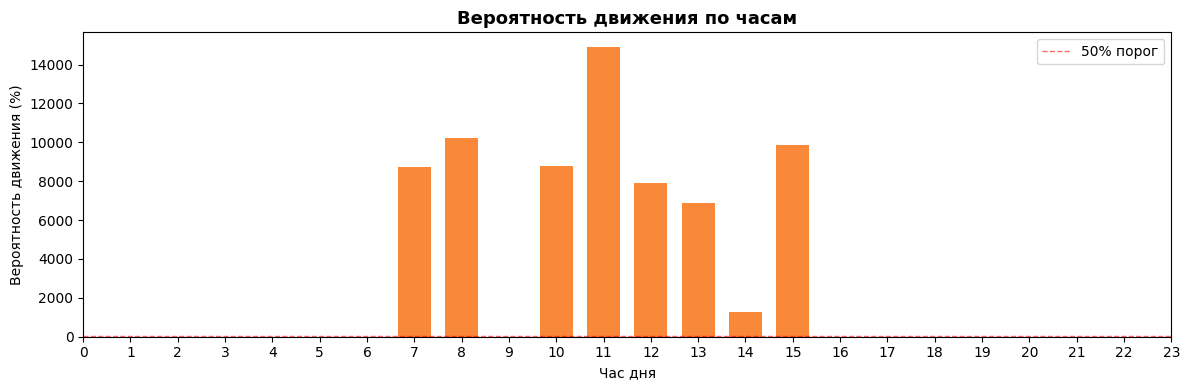

 Высокая активность (>50%): часы [7, 8, 10, 11, 12, 13, 14, 15]
 Низкая активность (<20%):  часы []
   ML включит свет ЗАРАНЕЕ в часы высокой активности.


In [42]:
hourly = df_feat.groupby('hour')['motion'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(hourly.index, hourly.values,
              color=['#F97316' if v > 50 else '#3B82F6' for v in hourly.values],
              width=0.7, alpha=0.85)
ax.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.6, label='50% порог')
ax.set_xlabel('Час дня'); ax.set_ylabel('Вероятность движения (%)')
ax.set_title('Вероятность движения по часам', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(); plt.tight_layout(); plt.show()

high = sorted([h for h, v in hourly.items() if v > 50])
low  = sorted([h for h, v in hourly.items() if 0 < v < 20])
print(f' Высокая активность (>50%): часы {high}')
print(f' Низкая активность (<20%):  часы {low}')
print('   ML включит свет ЗАРАНЕЕ в часы высокой активности.')


In [43]:
window = df_feat.head(100)
predictions_ahead = 0
examples = []

for i in range(len(window) - 4):
    cur  = window.iloc[i]
    fut  = window.iloc[i+1:i+5]
    feat = pd.DataFrame([{
        'hour': int(cur['hour']), 'minute': int(cur['minute']),
        'temperature': cur['temperature'], 'humidity': cur['humidity'],
        'light': cur['light']
    }])
    pred = model.predict(feat)[0]
    proba = model.predict_proba(feat)[0][1]
    actual_future_motion = fut['motion'].max()

    if pred == 1 and cur['motion'] == 0 and actual_future_motion == 1:
        predictions_ahead += 1
        t_cur = window.index[i].strftime('%H:%M:%S')
        t_fut_idx = fut[fut['motion'] == 1].index
        t_fut = t_fut_idx[0].strftime('%H:%M:%S') if len(t_fut_idx) else '?'
        examples.append((t_cur, t_fut, proba))

print(f'✓ Предсказаний движения ДО факта: {predictions_ahead}')
print('\n── Примеры предиктивных срабатываний')
for t_c, t_f, p in examples[:10]:
    print(f'  [{t_c}] → ML сработал  (уверенность: {p:.1%})')
    print(f'           → реальное движение зафиксировано в [{t_f}]')


✓ Предсказаний движения ДО факта: 9

── Примеры предиктивных срабатываний
  [13:24:30] → ML сработал  (уверенность: 66.0%)
           → реальное движение зафиксировано в [13:24:54]
  [13:31:13] → ML сработал  (уверенность: 64.0%)
           → реальное движение зафиксировано в [13:33:38]
  [13:31:55] → ML сработал  (уверенность: 74.0%)
           → реальное движение зафиксировано в [13:33:38]
  [13:43:49] → ML сработал  (уверенность: 60.0%)
           → реальное движение зафиксировано в [13:46:37]
  [13:44:50] → ML сработал  (уверенность: 96.0%)
           → реальное движение зафиксировано в [13:46:37]
  [13:45:11] → ML сработал  (уверенность: 99.0%)
           → реальное движение зафиксировано в [13:46:37]
  [13:45:55] → ML сработал  (уверенность: 99.0%)
           → реальное движение зафиксировано в [13:46:37]
  [13:46:58] → ML сработал  (уверенность: 99.0%)
           → реальное движение зафиксировано в [13:48:47]
  [13:47:39] → ML сработал  (уверенность: 72.0%)
           → реальное

In [44]:

def process_sensor_data(temperature, humidity, light, motion, voc):
    """
    Полный ML-пайплайн: получает показания датчиков,
    возвращает JSON-совместимый dict для PWA.
    """
    now = datetime.now()
    feat = pd.DataFrame([{
        'hour': now.hour, 'minute': now.minute,
        'temperature': temperature, 'humidity': humidity, 'light': light
    }])
    pred  = int(model.predict(feat)[0])
    proba = float(round(model.predict_proba(feat)[0][1], 3))

    alerts = learner.check(temperature, humidity, voc)

    light_action = 'ON' if (motion or pred) else 'OFF'

    return {
        'timestamp'        : now.isoformat(),
        'light_action'     : light_action,
        'predictive_trigger': bool(pred and not motion),
        'motion_confidence': proba,
        'alerts'           : alerts,
        'sdg_score'        : scores['overall']
    }


result = process_sensor_data(
    temperature=25.5, humidity=40, light=200, motion=0, voc=180
)
print('── API Response ')
print(json.dumps(result, ensure_ascii=False, indent=2))


── API Response 
{
  "timestamp": "2026-05-28T09:19:27.431716",
  "light_action": "ON",
  "predictive_trigger": true,
  "motion_confidence": 0.66,
  "alerts": [
    "🌡 Жарко: 25.5°C > 22.7°C",
    "🪟 Плохой воздух: VOC 180 > -5"
  ],
  "sdg_score": 80
}


In [45]:

print('  SMART HOME IoT — ML PIPELINE SUMMARY')

print(f'  Записей в датасете  : {len(df_clean)}')
print(f'  Дней наблюдений     : {df_clean.index.normalize().nunique()}')
print(f'  Признаков для модели: {len(FEATURE_COLS)}  ({FEATURE_COLS})')
print(f'  Accuracy (RF)       : {acc*100:.1f}%')
print(f'  Предиктивных срабат.: {predictions_ahead}')
print(f'  SDG Overall Score   : {scores["overall"]}%')

print('  Компоненты:')
print('    ✓ Random Forest — предсказание движения за 2 мин')
print('    ✓ SmartLight    — предиктивное управление реле')
print('    ✓ Z-score       — обнаружение аномалий')
print('    ✓ LinReg        — тренды + 30-мин прогноз')
print('    ✓ PersonalComfortLearner — персональные пороги')
print('    ✓ SDG Scoring   — оценка вклада в ЦУР 3,7,11,13')
print('    ✓ API-функция   — интеграция с PWA')



  SMART HOME IoT — ML PIPELINE SUMMARY
  Записей в датасете  : 964
  Дней наблюдений     : 7
  Признаков для модели: 5  (['hour', 'minute', 'temperature', 'humidity', 'light'])
  Accuracy (RF)       : 95.3%
  Предиктивных срабат.: 9
  SDG Overall Score   : 80%
  Компоненты:
    ✓ Random Forest — предсказание движения за 2 мин
    ✓ SmartLight    — предиктивное управление реле
    ✓ Z-score       — обнаружение аномалий
    ✓ LinReg        — тренды + 30-мин прогноз
    ✓ PersonalComfortLearner — персональные пороги
    ✓ SDG Scoring   — оценка вклада в ЦУР 3,7,11,13
    ✓ API-функция   — интеграция с PWA
